# Minimum Backtest Length — how long must a track record be to trust a Sharpe? 📅
### Why a five-year backtest usually *can't* prove your strategy works, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Short_backtests_fool_you%3F: Confirmed](https://img.shields.io/badge/Short_backtests_fool_you%3F-Confirmed-8b949e?style=flat-square)

Every strategy pitch leads with a **Sharpe ratio** — return per unit of risk — measured on a backtest. Almost none tells you the one thing that makes it interpretable: **how long the backtest is.** A Sharpe measured over a short history is a *noisy* number, and below a certain length any Sharpe, however gorgeous, is statistically indistinguishable from a coin flip.

Bailey, Borwein & López de Prado (2014) turned that into a hard rule: the **Minimum Track Record Length (MinTRL)** — the shortest history over which a Sharpe of a given size clears a 95% significance bar. We'll see it explode as the Sharpe falls, watch a *worthless* strategy post a brilliant backtest by pure luck, and confirm that even a *genuine* edge hides in a short window.

> 📓 **This is the plain-language layer.** Want the MinTRL/PSR formulas, the skew/kurtosis correction and the Monte-Carlo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it, on a deterministic **synthetic** world (no real data — the only way to fix the truth). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from min_backtest_length import data, strategy as st
Z = float(stats.norm.ppf(0.95))
print("synthetic-only method demo | daily freq %d, conf 0.95 (Z=%.4f), ann-vol %.2f, seed %d | fp %s"
      % (data.TRADING_DAYS, Z, data.ANN_VOL, data.BASE_SEED, data.config_fingerprint()))


synthetic-only method demo | daily freq 252, conf 0.95 (Z=1.6449), ann-vol 0.15, seed 834 | fp c648fb3ad2b5


## The answer first 🎯

| Question | Answer |
|---|---|
| How long to trust a **Sharpe-1** backtest? | **~2.71 years** (95% confidence, Gaussian daily). |
| A **Sharpe-0.5** idea (typical of real strategies)? | **~11 years.** Halve the Sharpe, *quadruple* the wait. |
| A **Sharpe-0.25** idea? | **~43 years** — longer than most careers. |
| Can a *worthless* strategy fake a great backtest? | **Yes.** Over 2 years, **8.4%** of zero-edge strategies post a Sharpe ≥ 1.0 by luck. |
| Do fat tails / crash risk make it worse? | **Yes** — a negatively-skewed, fat-tailed track needs **×1.65** longer. |

> The rule of thumb: you need about **(Z / Sharpe)² years** of history — and if you have less, the number on the slide is luck, not skill.

## 1 · The claim

> *"Given a target Sharpe ratio, there is a minimum length of track record below which you cannot tell a real edge from luck."*

A Sharpe ratio is your average return divided by how much it wobbles. Measure it over a handful of years and the estimate itself wobbles — a lot. The shorter the record, the wider the error bar, until the bar is so wide it comfortably includes **zero** (no skill at all).

## 2 · So what?

Because allocators wire billions on the strength of a backtest. If a mediocre, no-edge strategy can show a Sharpe of 1 over two years *by chance*, then the number is nearly worthless without knowing how long — and how the returns are shaped. The desk has shown you can fake a Sharpe by **searching** many rules ([344 Backtest-Overfitting](../../344-backtest-overfitting/)); here the trap is simpler and even more common — a **single honest strategy** with a track record that is just **too short**.

## 3 · How would we even know?

We can't ask a real strategy 'do you truly have edge?' — but in a **built** world we know the answer. So we make two: a **worthless** tape (true Sharpe exactly 0) and a **skilful** one (true Sharpe 1). Then we ask how long a backtest has to be before the maths can tell them apart. The MinTRL formula gives the threshold; a Monte-Carlo of thousands of backtests checks it holds.

## 4 · The teardown — the length you need explodes as the Sharpe falls

The MinTRL is analytic and instant to compute. Plot it against the target Sharpe (95% confidence, Gaussian daily returns):

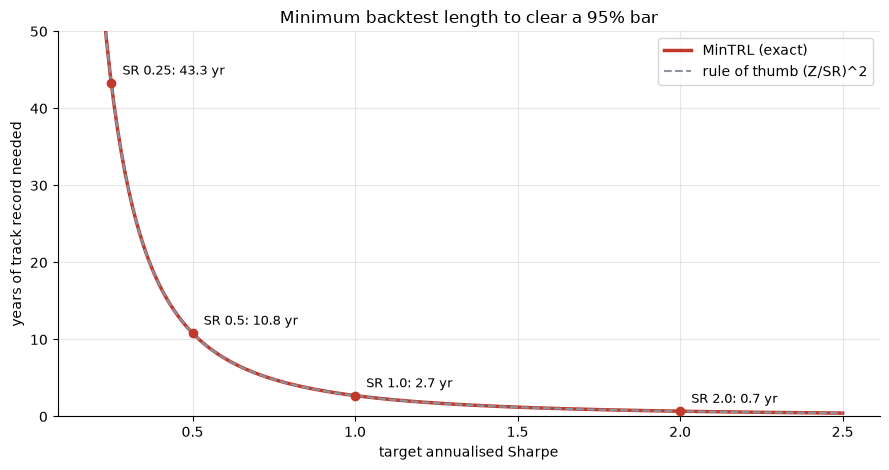

Sharpe  2.0:  need   0.69 years
Sharpe  1.0:  need   2.71 years
Sharpe  0.5:  need  10.83 years
Sharpe 0.25:  need  43.30 years


In [2]:
sr = np.linspace(0.2, 2.5, 200)
mtl = st.min_trl_curve(sr, freq=data.TRADING_DAYS, conf=0.95)
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(sr, mtl, c=RED, lw=2.5, label='MinTRL (exact)')
ax.plot(sr, (Z/sr)**2, '--', c=GREY, lw=1.5, label='rule of thumb (Z/SR)^2')
for s, yr, _ in [(2.0, 0.69, 0), (1.0, 2.71, 0), (0.5, 10.83, 0), (0.25, 43.30, 0)]:
    ax.scatter([s], [yr], color=RED, zorder=5)
    ax.annotate(f'SR {s}: {yr:.1f} yr', (s, yr), textcoords='offset points',
                xytext=(8, 6), fontsize=9)
ax.set_xlabel('target annualised Sharpe'); ax.set_ylabel('years of track record needed')
ax.set_ylim(0, 50); ax.set_title('Minimum backtest length to clear a 95% bar')
ax.legend(); plt.tight_layout(); plt.show()
for s in (2.0, 1.0, 0.5, 0.25):
    print(f'Sharpe {s:>4}:  need {st.min_trl_years(s, conf=0.95):6.2f} years')

There it is. A **Sharpe-1** strategy needs **2.71 years**; a **Sharpe-0.5** one (the honest reality for most systematic strategies) needs **11 years**; a **Sharpe-0.25** one needs **43 years**. The curve is a *quadratic* — halving the Sharpe quadruples the wait — because the noise in a Sharpe estimate only shrinks with the square root of the length.

**Now the punchline: a worthless strategy can look brilliant in a short window.** We draw 4,000 two-year backtests of a tape with *zero* real edge and count how many post a Sharpe ≥ 1.0 by luck:

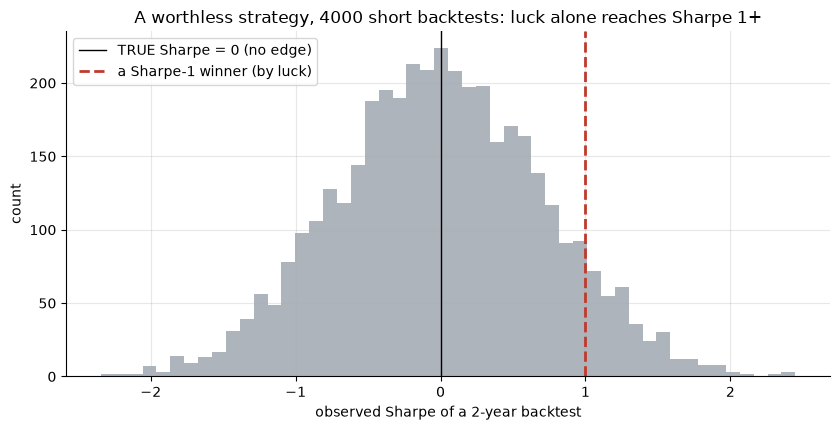

over 1 year :  15.6% of WORTHLESS backtests post Sharpe >= 1.0 (luckiest 3.40)
over 2 years:   8.4% of WORTHLESS backtests post Sharpe >= 1.0 (luckiest 2.45)
observed-Sharpe scatter at 2yr: sd 0.72 around 0


In [3]:
lp2 = st.luck_prob(data, threshold_sr=1.0, n_years=2.0, n_sims=4000, seed=834)
lp1 = st.luck_prob(data, threshold_sr=1.0, n_years=1.0, n_sims=4000, seed=834)
sim0 = st.simulate(data, sr_ann_true=0.0, n_years=2.0, n_sims=4000, seed=834)
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.hist(sim0['sr_obs'], bins=50, color=GREY, alpha=.7)
ax.axvline(0, c='k', lw=1, label='TRUE Sharpe = 0 (no edge)')
ax.axvline(1.0, c=RED, lw=2, ls='--', label='a Sharpe-1 winner (by luck)')
ax.set_xlabel('observed Sharpe of a 2-year backtest'); ax.set_ylabel('count')
ax.set_title('A worthless strategy, 4000 short backtests: luck alone reaches Sharpe 1+')
ax.legend(); plt.tight_layout(); plt.show()
print(f"over 1 year : {lp1['frac']*100:5.1f}% of WORTHLESS backtests post Sharpe >= 1.0 "
      f"(luckiest {lp1['best_sr']:.2f})")
print(f"over 2 years: {lp2['frac']*100:5.1f}% of WORTHLESS backtests post Sharpe >= 1.0 "
      f"(luckiest {lp2['best_sr']:.2f})")
print(f"observed-Sharpe scatter at 2yr: sd {sim0['sd_obs_sr']:.2f} around 0")

Over two years, **8.4%** of these zero-skill strategies clear a Sharpe of 1.0 — and the luckiest posts **2.45**. The observed Sharpe of a *worthless* two-year backtest scatters with a standard deviation of **0.717** around zero. If you run enough short backtests, a gorgeous one is *guaranteed*, with no skill involved.

## 5 · The verdict

- **Signal — None.** On a world built with zero edge there is nothing real to find; the only pretty backtest is luck.
- **Tradability — Mirage.** A backtest shorter than its MinTRL is a coin flip — nothing to harvest.
- **Do short backtests fool you? — Confirmed.** The length you need grows as `(Z/SR)²` (43 years at Sharpe 0.25), and a worthless strategy fakes a Sharpe-1 backtest 8% of the time over two years.

## 6 · Could you actually 'trade' it?

There is nothing here to trade — that *is* the point. Before you allocate to any backtest, compute its MinTRL: if the history is shorter than `(Z/Sharpe)²` years, the Sharpe on the slide cannot be told apart from luck, and no amount of execution skill changes that. The honest move is to demand a longer record, a lower expectation, or both.

## 7 · Going further 🚪

- **The searching cousin.** [344 Backtest-Overfitting](../../344-backtest-overfitting/) and [833 Deflated-Sharpe](../../833-deflated-sharpe/) fake a Sharpe by *trying many strategies* and keeping the luckiest; this study shows even **one** honest strategy needs a long enough record.
- **The fat-tail twist (quants notebook).** Negative skew and fat tails — the profile of anything that sells crash insurance — make the required length *longer* still.

*Have a backtest you love? Fork this, plug in its Sharpe and length, and check whether it even clears its own MinTRL before you believe it.*